# Predict logP

The aim of this exercise is to compare model performance between a GNN and a supervised method to predict logP. 
Consider as a starting point one of the GNNs from session 14 (GCN, GIN, or GAT), and a supervised model of your choice (e.g., Random Forest with MACCS fingerprints).

#### Tasks:
1) Create a training and a test set
2) Build a supervised model of your choice on the training data and evaluate its performance on the test set
3) Build a GNN and compare its performance to the supervised model
4) Discuss the outcome


In [106]:
# complete imports if needed for your solution
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import MACCSkeys
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error


import torch #installed torch_geometric by terminal "uv add torch_geometric"
import torch.nn.functional as Fun
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU
from torch_geometric.nn import GCNConv, GINConv, GATConv
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, global_add_pool
from torch_geometric.data import Data

Load the data from Session 11

In [107]:
df = pd.read_csv(os.path.join("..", "..", "lectures", "session11", "material", "esol_modified.csv")).dropna(subset=["SMILES"])
df = df.loc[df.SMILES != 'C'] # remove the one compound containing only a single atom
df.head()


,SMILES,LogS,MolWt,LogP,EState_VSA5,TPSA,NumHAcc,NumAromaticRings,HeavyAtomCount,RingCount,qed,NumHDonors,NOCount
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,457.432,-3.10802,0.000000,202.32,12.0,1.0,32.0,3.0,0.217518,7.0,12.0
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,201.225,2.84032,6.263163,42.24,2.0,2.0,15.0,2.0,0.811283,1.0,3.0
2,CC(C)=CCCC(C)=CC(=O),-2.06,152.237,2.87800,5.573105,17.07,1.0,0.0,11.0,0.0,0.343706,0.0,1.0
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,278.354,6.29940,43.089794,0.00,0.0,5.0,22.0,5.0,0.291526,0.0,0.0
4,c1ccsc1,-1.33,84.143,1.74810,0.000000,0.00,1.0,1.0,5.0,1.0,0.448927,0.0,0.0


### Setting the stage
Split the data into training and test sets. The test set will be used to compare model performance.


In [108]:
X = df.drop("LogP", axis=1)
y = df["LogP"]

In [109]:
def smiles_to_mol(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return mol
def maccskeys(mol):
    fp = MACCSkeys.GenMACCSKeys(mol)
    return np.array(fp)

df["mol"] = df["SMILES"].apply(smiles_to_mol)

df["MACCSkeys"] = df["mol"].apply(maccskeys)
#df.head()

In [110]:
X = np.stack(df["MACCSkeys"].values) # joins multiple arrays along a new axis - builds a proper array from the line-by-line arrays in the df.
y = df["LogP"]

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [112]:
print("Feature matrix shape:", X.shape)
print("\nClass distribution:")
print(y.value_counts())

Feature matrix shape: (1127, 167)

Class distribution:
LogP
7.27400    7
1.41490    6
1.94750    6
6.62060    5
5.96720    5
          ..
2.72770    1
3.76770    1
2.78888    1
3.33810    1
5.60150    1
Name: count, Length: 930, dtype: int64


### Baseline supervised model
Choose a 
   - regression model (RF, SVR, kNN, Gradient Boost, ...) 
   - molecular descriptor (RDKit, Mordred, ...) or fingerprint (MACCS, Morgan, RDKit, ...)
      
Build a feature matrix and target vector. Add scaling if needed for your model.
Train the model on the training set and apply it to the test set.
Calculate performance metrics (R2, RMSE) for model performance on the test set.

In [113]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel='linear', C=100, 
                #gamma=0.5,
                epsilon=0.1))  # "balanced" can help if classes are imbalanced
])

In [114]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [115]:
y_pred = pipe.predict(X_test)
y_pred_train = pipe.predict(X_train)

In [116]:
rbf_r2 = r2_score(y_test, y_pred)
rbf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rbf_r2_train = r2_score(y_train, y_pred_train)
rbf_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))



print(f"SVR RBF: \n train r2: {rbf_r2_train:.4f} train RMSE {rbf_rmse_train:.4f}\n test  r2:{rbf_r2:.4f}  test  RMSE:{rbf_rmse:.4f}")

SVR RBF: 
 train r2: 0.8071 train RMSE 0.8078
 test  r2:0.6957  test  RMSE:1.0492


### RF bc I don't like the results

In [117]:
model=RandomForestRegressor(n_estimators=600, random_state=42)
name="Random Forest"
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [118]:
rf_y_train_pred = model.predict(X_train)
rf_y_test_pred = model.predict(X_test)
    
rf_train_mse = np.sqrt(mean_squared_error(y_train, rf_y_train_pred))
rf_test_mse = np.sqrt(mean_squared_error(y_test, rf_y_test_pred))
    
rf_train_r2 = r2_score(y_train, rf_y_train_pred)
rf_test_r2 = r2_score(y_test, rf_y_test_pred)

In [119]:
print(f"RF: \n train r2: {rf_train_r2:.4f} train RMSE {rf_train_mse:.4f}\n test  r2:{rf_test_r2:.4f}  test  RMSE:{rf_test_mse:.4f}")

RF: 
 train r2: 0.9307 train RMSE 0.4844
 test  r2:0.8134  test  RMSE:0.8215


### Unpervised GNN model
Choose a GNN architecture
   - GCN, GIN, or GAT
      
Transform input smiles to graph objects using the atom and bond features. Build graphs for both training and test set. Train the GNN on the training set. Adapt architecture and parameters until you are happy with the performance. Apply the trained model on the test set (once!) and calculate model performance metrics

In [120]:
def atom_features(atom): # Create a tensor for atom features, length = 5
    return torch.tensor([
        atom.GetAtomicNum(),
        atom.GetTotalDegree(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
        atom.GetTotalNumHs(),
    ], dtype=torch.float)

def bond_features(bond): # Create a tensor for bond features, length = 6
    bt = bond.GetBondType()
    return torch.tensor([
        bt == Chem.rdchem.BondType.SINGLE,
        bt == Chem.rdchem.BondType.DOUBLE,
        bt == Chem.rdchem.BondType.TRIPLE,
        bt == Chem.rdchem.BondType.AROMATIC,
        bond.GetIsConjugated(),
        bond.IsInRing(),
    ], dtype=torch.float)

In [121]:
def smiles_to_graph(smiles, y):
    mol = Chem.MolFromSmiles(smiles) # Create a RDKit mol object from the smiles

    # Calculate atom features for all atoms in the molecule
    x = torch.stack([atom_features(atom) for atom in mol.GetAtoms()], dim=0)

    # Edges
    edge_index = []
    edge_attr = []
    
    # Iterate through all bonds in the molecule
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        # Represent molecule as an undirected graph --> add both directions
        edge_index.append([i, j]) # left to right
        edge_index.append([j, i]) # right to left

        bf = bond_features(bond) # calculate bond features 
        edge_attr.append(bf)
        edge_attr.append(bf) # add two times, once for forward and once for backwards edge

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous() 
    edge_attr  = torch.stack(edge_attr, dim=0)

    # Target property: logP
    y = torch.tensor([y], dtype=torch.float)
    
    # x: atom stack, y: logP
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

In [122]:
graphs = [smiles_to_graph(row.SMILES, row.LogP) for _, row in df.iterrows()]

In [123]:
class GINModel(torch.nn.Module):
    def __init__(self, dim_h=64):
        super().__init__()

        nn1 = torch.nn.Sequential(
            torch.nn.Linear(5, dim_h),
            torch.nn.ReLU(),
            torch.nn.Linear(dim_h, dim_h)
        )
        nn2 = torch.nn.Sequential(
            torch.nn.Linear(dim_h, dim_h),
            torch.nn.ReLU(),
            torch.nn.Linear(dim_h, dim_h)
        )
        nn3 = torch.nn.Sequential(
        torch.nn.Linear(dim_h, dim_h),
        torch.nn.ReLU(),
        torch.nn.Linear(dim_h, dim_h)
        )
        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)
        self.conv3 = GINConv(nn3)

        self.lin = torch.nn.Linear(dim_h, 1)

    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))
        x = torch.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch) # try: global_add_pool(x, batch)
        return self.lin(x).squeeze(-1)


In [124]:
def train(model, train_loader, val_loader, epochs=30, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # lr: learning rate
    criterion = torch.nn.MSELoss() # loss function

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for batch in train_loader:
            optimizer.zero_grad() # Reset gradients
            pred = model(batch.x, batch.edge_index, batch.batch) # predict on batch
            loss = criterion(pred, batch.y) # define criterion
            loss.backward() # computes the gradient of the loss
            optimizer.step() # Perform an optimization step
            train_losses.append(loss.item())

        val_loss = evaluate(model, val_loader) # evaluate re-trained model on validation data
        if epoch %100==0:
            print(f"Epoch {epoch:02d} | "
                f"Train Loss = {sum(train_losses)/len(train_losses):.4f} | " # average train loss
                f"Val Loss = {val_loss:.4f}") 
        loss_return= sum(train_losses)/len(train_losses)
    return loss_return, val_loss

def test(model, test_loader):
    test_loss = evaluate(model, test_loader)
    print(f"\nTest Loss: {test_loss:.4f}")
    return test_loss


In [125]:
def create_splits(graphs, train_ratio=0.8, val_ratio=0.1, seed=42):
    torch.manual_seed(seed)
    graphs = graphs.copy()
    permutation = torch.randperm(len(graphs))
    graphs = [graphs[i] for i in permutation]

    n = len(graphs)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_graphs = graphs[:n_train]
    val_graphs   = graphs[n_train:n_train + n_val]
    test_graphs  = graphs[n_train + n_val:]

    return train_graphs, val_graphs, test_graphs

train_graphs, val_graphs, test_graphs = create_splits(graphs)

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=32)
test_loader  = DataLoader(test_graphs, batch_size=32)

In [126]:
def evaluate(model, loader):
    model.eval()
    criterion = torch.nn.MSELoss()
    losses = []

    with torch.no_grad():
        for batch in loader:
            pred = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(pred, batch.y)
            losses.append(loss.item())

    return sum(losses) / len(losses)

In [127]:
loader = DataLoader(graphs, batch_size=100, shuffle=True)

In [128]:
# training GCN for 10 epochs

gin = GINModel()

epochs = 500

print("\n=== Training GIN ===")
loss_return, val_loss = train(gin, train_loader, val_loader, epochs=epochs)
gin_loss=test(gin, test_loader)




=== Training GIN ===
Epoch 00 | Train Loss = 4.2829 | Val Loss = 3.9726
Epoch 100 | Train Loss = 0.9533 | Val Loss = 0.8179
Epoch 200 | Train Loss = 0.6340 | Val Loss = 0.7127
Epoch 300 | Train Loss = 0.4577 | Val Loss = 0.6568
Epoch 400 | Train Loss = 0.3697 | Val Loss = 0.6422

Test Loss: 0.8056


In [129]:
import matplotlib.pyplot as plt
def parity_plot(model, test_loader, title="Parity Plot (Test Set)"):
    model.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for batch in test_loader:
            pred = model(batch.x, batch.edge_index, batch.batch)

            # Ensure correct shapes
            pred = pred.view(-1).cpu()
            y = batch.y.view(-1).cpu()

            preds.append(pred)
            trues.append(y)

    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()

    # Parity plot
    plt.figure(figsize=(5,5))
    plt.scatter(trues, preds, alpha=0.6)
    plt.plot([trues.min(), trues.max()],
             [trues.min(), trues.max()],
             color='red', linestyle='--', linewidth=2)

    plt.xlabel("True logP")
    plt.ylabel("Predicted logP")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Usage:

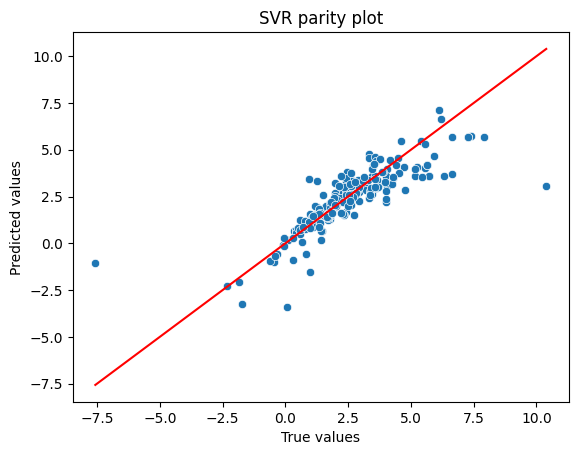

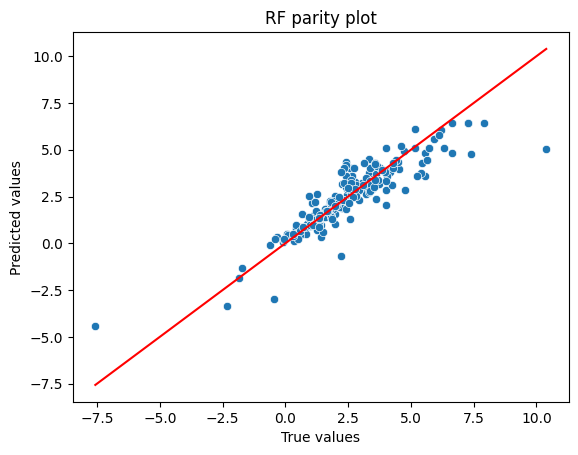

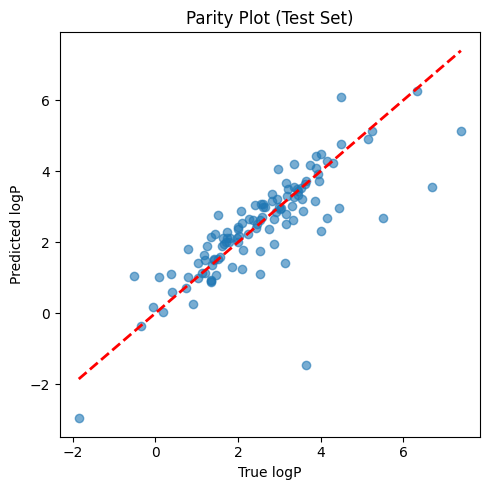

In [130]:
import seaborn as sns
sns.scatterplot(x=y_test, y=y_pred)

# perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red")

plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("SVR parity plot")
plt.show()

sns.scatterplot(x=y_test, y=rf_y_test_pred)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red")
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("RF parity plot")
plt.show()

parity_plot(gin, test_loader)

In [131]:
print(f"SVR RBF: \n train r2: {rbf_r2_train:.4f} train RMSE {rbf_rmse_train:.4f}\n test  r2:{rbf_r2:.4f}  test  RMSE:{rbf_rmse:.4f}")
print(f"RF: \n train r2: {rf_train_r2:.4f} train RMSE {rf_train_mse:.4f}\n test  r2:{rf_test_r2:.4f}  test  RMSE:{rf_test_mse:.4f}")
print(f"GIN : \n Test Loss: {gin_loss:.4f} | Train Loss = {loss_return:.4f} | Val Loss = {val_loss:.4f}")


SVR RBF: 
 train r2: 0.8071 train RMSE 0.8078
 test  r2:0.6957  test  RMSE:1.0492
RF: 
 train r2: 0.9307 train RMSE 0.4844
 test  r2:0.8134  test  RMSE:0.8215
GIN : 
 Test Loss: 0.8056 | Train Loss = 0.2678 | Val Loss = 0.6134


### Discussion points
1) Which model (supervised or unsupervised) performed better on the test set, and why?
2) What did you try to improve model performance of your GNN? What did work, what did not work?
3) Which challenges did you face in the process of building the models?
4) Which of your two models would you recommend to a chemist for predicting logP, and why?

1) RF performed best, the GIN model also did well though. idk if I'm missing something but I'm not sure how to compare them since they use different metrics. Visually the parity plots between the RF and GIN seem similar. The SVR RBF performed better once I set the kernel to linear, but it's overfitting (RF as well) and has poor performance on the test set. I only chose SVR bc I've not had as much experience with it. 

RF works well because it's always random, I gave it a lot of estimators though (600), which definitly helped it's prediction properties. 
With the SVR I could have maybe incorporated a PCA. As it seems though the data doesn't need to be transformed into higher dims (idea behind SVR?).
In GIN each node looks at it's neighbours and aggregates the info, once the smiles have been transformed into  graph. I used it bc in the lecture we said it was suitable to represent molecules. 

2) tried giving it more epochs, but it stalls at around 400, so I did 500 just to be sure. I increased and decreased the lr but to no (or negative) effect. I added a conv layer, this helped. 

3) The SVR I wasn't sure how to proceed / handle the data. How to scale etcs. (maybe that's the problem), or which parameters to adjust or weather or not to use a CVgridSearch (time). It also takes a long time to run, so it's inexact and slow (1min 45s). GIN I already had the code, so no problems, just trying things out, kind iof slow (25 sek, we only have 1k data points....). 

4) Personally RF, not 100% reliable but the parameters could still be optimised (GridSearchCV). It's a lot less code and data transformation (vs. GIN make mols to graphs etc.) if that matters. It only took 2s to run, but we also only have 1k data points. Honestly I'd recment a chemist to use a pretrained model. 

> Jasmin says MACCSKEYS and RF fir best results,

> why does the GNN not overfit after a lot of epochs? -> model is just right :)

> why overfitting? when model too complex for data 
